In [1]:
import numpy as np
import napari
from math import sqrt
from skimage.filters import median, threshold_otsu
from skimage import morphology
from tifffile import imread
from scipy import ndimage as ndi
import cv2 as cv
import numpy as np
import os

In [10]:
def read_data(path, viewer):
    ''' Input: path to the data file
        Output: 4 separate channels of image data
        Function sends the data to napari viewer '''
    data = imread(path)
    data = (data / data.max() * 255).astype('uint8') # convert to 8-bit
    image_data = [data[0], data[1], data[2], data[3], data[4]]
    channels = ['c1', 'c2', 'c3', 'c4', "c5"]
    colors = ['gray', 'green', 'blue', 'red', "gray"]
    for img, ch, color in zip(image_data, channels, colors):
        viewer.add_image(img, name=ch, colormap=color, blending='additive', contrast_limits=[0, 150])
    return data[0], data[1], data[2], data[3], data[4]

In [2]:
# run napari
viewer = napari.Viewer()

Cannot move to target thread (0x25761b020d0)


Available platform plugins are: minimal, offscreen, webgl, windows.



: 

: 

In [12]:
# import data
path = "C:/Users/zuzka/Desktop/rasy/"
name = '2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-N2_6median' # name of a file
ch1,ch2,ch3,ch4,ch5 = read_data(path + name +".tif", viewer) # specify the path if different

NameError: name 'plt' is not defined

In [ ]:
# mask
blurred = median(ch2, np.ones((20, 20)))
threshold_value = threshold_otsu(blurred, 10)
thresholded = blurred > 10
fill_holes = ndi.binary_fill_holes(thresholded)
viewer.add_image(thresholded, name="thresholded")
viewer.add_image(fill_holes, name="filled")

In [38]:
# skeleton
from skimage.morphology import medial_axis, skeletonize
skeleton = skeletonize(fill_holes)
viewer.add_labels(skeleton, name="skeleton")
skel, distance = medial_axis(fill_holes, return_distance=True)
dist_on_skel = distance * skel
viewer.add_labels(skel, name="medial")
viewer.add_image(dist_on_skel, name="dist", colormap="magma")


ModuleNotFoundError: No module named 'dsepruning'

In [42]:
conda install -c conda-forge skan

Note: you may need to restart the kernel to use updated packages.

Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\zuzka\anaconda3\envs\idt-allen-brain-map-reg

  added / updated specs:
    - skan


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    contourpy-1.0.7            |   py39h1f6ef14_0         156 KB  conda-forge
    fonttools-4.38.0           |   py39ha55989b_1         1.7 MB  conda-forge
    kiwisolver-1.4.4           |   py39h1f6ef14_1          58 KB  conda-forge
    llvmlite-0.39.1            |   py39hd28a505_1        16.2 MB  conda-forge
    matplotlib-base-3.6.3      |   py39haf65ace_0         6.2 MB  conda-forge
    numba-0.56.4               |   py39h99ae161_0         3.5 MB  conda-forge
    openpyxl-3.0.10            |   py39ha55989b_2         503 KB  conda-forge
    skan-0.10.0                |     pyhd8ed1ab_0         1.5 MB 



==> WARNING: A newer version of conda exists. <==
  current version: 4.12.0
  latest version: 22.11.1

Please update conda by running

    $ conda update -n base conda




In [46]:
#from dsepruning import skel_pruning_DSE
from skan import csr

graph_class = csr.Skeleton(skel)
# get statistics for each branch, especially relevant the length and type of branch here
stats = csr.branch_statistics(graph_class.graph)

# remove all branches which are shorter than the threshold value and a tip-junction (endpoint to junction) branch
thres_min_size = 100
for ii in range(np.size(stats, axis=0)):
    if stats[ii,2] < thres_min_size and stats[ii,3] == 1:
        # remove the branch
        for jj in range(np.size(graph_class.path_coordinates(ii), axis=0)):
            skel[int(graph_class.path_coordinates(ii)[jj,0]), int(graph_class.path_coordinates(ii)[jj,1])] = False

# during the short branch removing process it can happen that some branches are not longer connected as the complete three branches intersection is removed
# therefor the remaining skeleton is dilatated and then skeletonized again
sk_dilation = morphology.binary_dilation(skel)
sk_final = morphology.skeletonize(sk_dilation)
viewer.add_labels(sk_final, name="pruned")


<Image layer 'dist [4]' at 0x247022ce430>

In [57]:
skfi = sk_final.astype("int")
viewer.add_image(skfi, name="pruned")


<Image layer 'pruned' at 0x24704ea7bb0>

In [59]:
skfi.shape

(600, 3232)

In [85]:
np.count_nonzero(skfi == 1)

3230

In [92]:
# nn-pixels
nearest_neighbor = ndi.morphology.distance_transform_edt(skfi==0, return_distances=False, return_indices=True)
nearest_neighbor


C:\Users\zuzka\AppData\Local\Temp\ipykernel_20680\1479602844.py:2: DeprecationWarning: Please use `distance_transform_edt` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  nearest_neighbor = ndi.morphology.distance_transform_edt(skfi==0, return_distances=False, return_indices=True)


array([[[   1,    1,    1, ...,  371,  371,  371],
        [   1,    1,    1, ...,  371,  371,  371],
        [   2,    2,    2, ...,  371,  371,  371],
        ...,
        [ 327,  327,  327, ...,  371,  371,  371],
        [ 327,  327,  327, ...,  371,  371,  371],
        [ 327,  327,  327, ...,  371,  371,  371]],

       [[   0,    0,    0, ..., 3105, 3105, 3105],
        [   0,    0,    0, ..., 3105, 3105, 3105],
        [   0,    0,    0, ..., 3105, 3105, 3105],
        ...,
        [ 214,  214,  214, ..., 3105, 3105, 3105],
        [ 214,  214,  214, ..., 3105, 3105, 3105],
        [ 214,  214,  214, ..., 3105, 3105, 3105]]])

In [ ]:
layer = viewer.add_labels(nearest_neighbor[0], name="nn")
layer.data

In [106]:
skfi.shape[0]

600

In [122]:
def labeler(mat):
    x,y = mat.shape[2], mat.shape[1]
    a = np.zeros(shape=(y, x))
    for i in range(x):
        for ii in range(y):
            ind = int(str(nearest_neighbor[0][ii][i]) + str(nearest_neighbor[1][ii][i]))
            a[ii,i] = ind
    a = a.astype(int)
    return(a)

In [123]:
new_mat = labeler(nearest_neighbor)

In [124]:
new_mat

array([[     10,      10,      10, ..., 3713105, 3713105, 3713105],
       [     10,      10,      10, ..., 3713105, 3713105, 3713105],
       [     20,      20,      20, ..., 3713105, 3713105, 3713105],
       ...,
       [ 327214,  327214,  327214, ..., 3713105, 3713105, 3713105],
       [ 327214,  327214,  327214, ..., 3713105, 3713105, 3713105],
       [ 327214,  327214,  327214, ..., 3713105, 3713105, 3713105]])

In [118]:
new_mat.shape

(600, 3232)

In [125]:
layer = viewer.add_labels(new_mat, name="nn")


In [132]:
fill_holes.shape

(600, 3232)

In [138]:
test = fill_holes.astype(int)

In [146]:
segmented = new_mat * test
segmented.shape
skeleton_mask = new_mat * skfi.astype(int)

In [140]:
segmented

array([[10, 10, 10, ...,  0,  0,  0],
       [10, 10, 10, ...,  0,  0,  0],
       [20, 20, 20, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

In [147]:
layer = viewer.add_labels(segmented, name="nn")
layer = viewer.add_labels(skeleton_mask, name="snn")

In [143]:
unique, counts = np.unique(segmented, return_counts=True)
unique

array([      0,      10,      20, ..., 3962758, 3972747, 3972748])

In [145]:
segmented == 10

array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [150]:
skeleton_mask

array([[ 0,  0,  0, ...,  0,  0,  0],
       [10,  0,  0, ...,  0,  0,  0],
       [20,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

In [209]:
segmented

array([[10, 10, 10, ...,  0,  0,  0],
       [10, 10, 10, ...,  0,  0,  0],
       [20, 20, 20, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])

In [159]:
np.where(skeleton_mask==30)[1][0]

0

In [238]:
skfi2 = np.zeros(shape=(600, 3232))
skfi3 = np.zeros(shape=(600, 3232))



In [166]:
skfi2[0,1] = 2

In [223]:
import math

2

In [230]:
print( np.mean(ch2[mask]), np.mean(ch4[mask]))

24.2625 50.9


In [236]:
skfi[2, 0] = int(150.9)
skfi[2, 0]

150

In [240]:
for u in unique:
    mask = segmented == u
    meanch2 = np.mean(ch2[mask])
    col_sp = np.where(skeleton_mask==u)[1][0]
    row_sp = np.where(skeleton_mask==u)[0][0]
    skfi2[row_sp, col_sp] = int(round(meanch2))

In [241]:
for u in unique:
    mask = segmented == u
    meanch4 = np.mean(ch4[mask])
    col_sp = np.where(skeleton_mask==u)[1][0]
    row_sp = np.where(skeleton_mask==u)[0][0]
    skfi3[row_sp, col_sp] = int(round(meanch4))

In [242]:
layer = viewer.add_image(skfi2, name="medial_axis_mean_projection_g")
layer = viewer.add_image(skfi3, name="medial_axis_mean_projection_r")

In [177]:
import matplotlib

In [229]:
print( ch4[383,3121], ch2[383,3121])
print( ch4[377,3110], ch2[377,3110])


64 55
87 41


In [190]:
skfi2.sum(axis=0)

array([1770,   26,   25, ...,    0,    0,    0])

In [198]:
(skfi2.sum(axis=0))[1:]

array([1770,   26,   25, ...,    0,    0,    0])

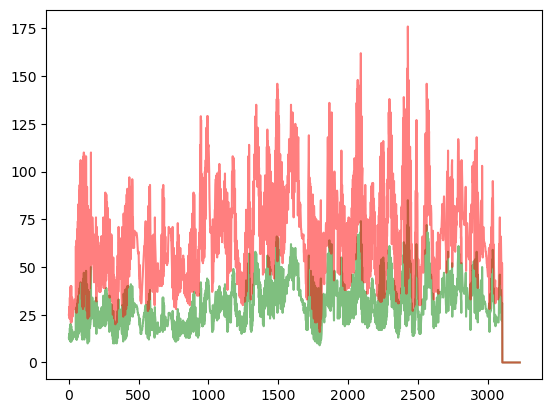

In [243]:
import matplotlib.pyplot as plt
plt.plot(skfi2.sum(axis=0)[1:], alpha = 0.5, color ="green")
plt.plot(skfi3.sum(axis=0)[1:], alpha = 0.5, color="red")

In [244]:
from skimage import io

In [245]:
io.imsave(path+"testG.tiff", skfi2)
io.imsave(path+"testR.tiff", skfi3)

C:\Users\zuzka\AppData\Local\Temp\ipykernel_20680\794468184.py:1: UserWarning: C:/Users/zuzka/Desktop/rasy/testG.tiff is a low contrast image
  io.imsave(path+"testG.tiff", skfi2)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_20680\794468184.py:2: UserWarning: C:/Users/zuzka/Desktop/rasy/testR.tiff is a low contrast image
  io.imsave(path+"testR.tiff", skfi3)


 ...]

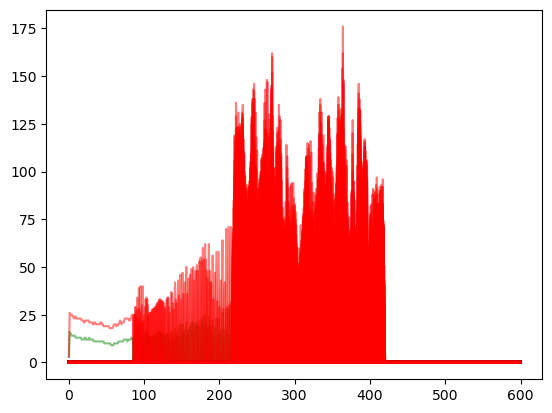

In [246]:
plt.plot(skfi2, alpha = 0.5, color ="green")
plt.plot(skfi3, alpha = 0.5, color="red")